In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df_results = pd.read_csv('results.csv')
df_goals = pd.read_csv('goalscorers.csv')
df_shootout = pd.read_csv('shootouts.csv')

In [3]:
df_results.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [4]:
df = df_results.dropna(subset=['home_score', 'away_score'], how='all')


In [5]:
df_shootout.isnull().sum()

date               0
home_team          0
away_team          0
winner             0
first_shooter    429
dtype: int64

In [6]:
df_goals.isnull().sum()

date           0
home_team      0
away_team      0
team           0
scorer        48
minute       256
own_goal       0
penalty        0
dtype: int64

In [7]:
def addcolumn(row):
    if row['home_score']> row['away_score']:
        return row['home_team']
    elif row['home_score']< row['away_score']:
        return row['away_team']
    else:
        return 'Draw'

     

In [8]:
df_results['winner']= df_results.apply(addcolumn,axis=1)

In [9]:
df_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,Draw
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,England
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,Scotland
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,Draw
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,Scotland


In [10]:
total_matches = len(df)

In [11]:
total_goal = (df_results['home_score'] + df_results['away_score']).sum()


In [12]:
total_team_name = pd.concat([df['home_team'], df['away_team']]).unique()
total_teams = len(total_team_name)

In [13]:
city = df_results['city'].value_counts()
most_played_city = city.index[0]
count_matches = city.iloc[0]

 

In [14]:
no_of_tournaments = len(df_results['tournament'].unique())
unique_tournaments = df_results['tournament'].unique()

In [15]:

home_counts = df_results.groupby('home_team').size()
away_counts = df_results.groupby('away_team').size()
matches_played = home_counts.add(away_counts, fill_value=0)

win_counts = df_results[df_results['winner'] != 'Draw'].groupby('winner').size()

win_rate = (win_counts / matches_played).dropna()

# ✅ filter teams with >= 50 matches
eligible_teams = matches_played[matches_played >= 250].index
win_rate = win_rate[win_rate.index.isin(eligible_teams)]

# best team
max_name = win_rate.idxmax()
max_rate = win_rate.max()
max_rate *= 100
min_rate = win_rate.min()
min_name = win_rate.idxmin()

In [16]:
max_rate

np.float64(63.20754716981132)

In [17]:
max_name

'Brazil'

In [18]:
min_rate

np.float64(0.07392996108949416)

In [19]:
min_name

'Liechtenstein'

In [20]:
goals_pie = len(df_goals)

In [21]:
goal_fhalf = (df_goals['minute']<=45).sum()
goal_shalf = ((df_goals['minute']<=90) & (df_goals['minute']>45) ).sum()
goal_extra = (df_goals['minute']>90).sum()

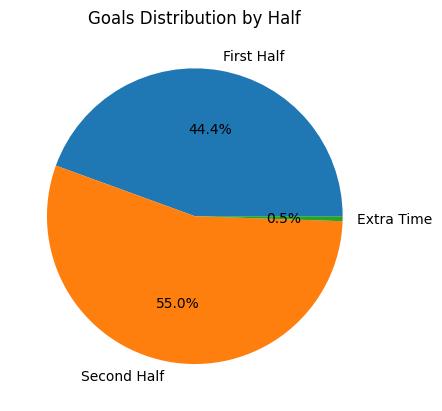

In [22]:
labels = ['First Half', 'Second Half','Extra Time']
sizes = [goal_fhalf, goal_shalf,goal_extra]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Goals Distribution by Half')
plt.show()

In [23]:
 open_play = ((df_goals['own_goal']==False) &(df_goals['penalty']==False)).sum()

In [24]:
penalty_goals = (df_goals['penalty']==True).sum()

In [25]:
own_goal = (df_goals['own_goal']==True).sum()

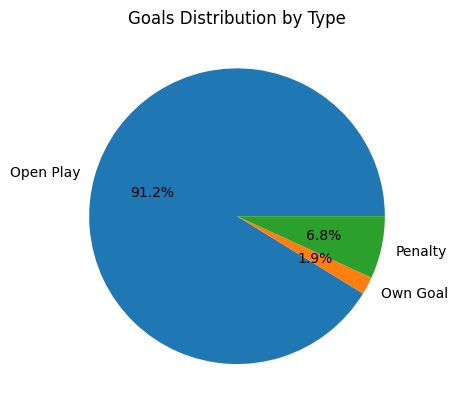

In [26]:
labels1 = ['Open Play', 'Own Goal','Penalty']
sizes1 = [open_play, own_goal,penalty_goals]

plt.pie(sizes1, labels=labels1, autopct='%1.1f%%')
plt.title('Goals Distribution by Type')
plt.show()

In [27]:
lead_goalscorers = df_goals['scorer'].value_counts().head(5)
lead_name = lead_goalscorers.index
lead_value_goal = lead_goalscorers.values

In [28]:
shootouts_known = df_shootout.dropna(subset=['first_shooter'])

shootouts_known['first_shooter_won'] = shootouts_known['first_shooter'] == shootouts_known['winner']

first_shooter_win_pct = shootouts_known['first_shooter_won'].mean() * 100

In [29]:
shootout_most_win = df_shootout['winner'].value_counts().head(5)
name_win_shootout = shootout_most_win.index
value_win_shootout = shootout_most_win.values

In [30]:
time_range_options = {'Past 1 Year': 1, 'Past 2 Years': 2, 'Past 5 Years': 5, 'Past 10 Years': 10,'Past 20 Years':20,'Past 50 Years':50,'Past 100 Years':100, 'All time': None}

In [31]:
prediction = pd.DataFrame()
prediction['Name'] = pd.Series(total_team_name).sort_values().values

In [32]:
df_results['date'] = pd.to_datetime(df_results['date'])

In [33]:
year_max = df_results['date'].dt.year.max()
df_recent = df_results[df_results['date'].dt.year >= year_max- 4]

In [34]:
home = df_recent[['home_team', 'home_score', 'away_score']].rename(columns={
    'home_team': 'team', 'home_score': 'scored', 'away_score': 'conceded'})
away = df_recent[['away_team', 'away_score', 'home_score']].rename(columns={
    'away_team': 'team', 'away_score': 'scored', 'home_score': 'conceded'})

combined = pd.concat([home, away])

goal_stats = combined.groupby('team').agg(
    total_scored=('scored', 'sum'),
    total_conceded=('conceded', 'sum')).reset_index()

goal_stats = (
    pd.DataFrame({'team': total_team_name})
    .merge(goal_stats, on='team', how='left')
    .fillna(0))

goal_stats['goals_ratio'] = np.where(
    goal_stats['total_conceded'] == 0,
    goal_stats['total_scored'],
    (goal_stats['total_scored'] / goal_stats['total_conceded']).round(2))


In [35]:
print(goal_stats.sort_values('goals_ratio', ascending=False))

                   team  total_scored  total_conceded  goals_ratio
8             Argentina         121.0            24.0         5.04
298        Székely Land          10.0             2.0         5.00
320         Elba Island           5.0             0.0         5.00
283         Tamil Eelam           9.0             2.0         4.50
23               Russia          58.0            14.0         4.14
..                  ...           ...             ...          ...
308          Kárpátalja           0.0             0.0         0.00
311            Cascadia           0.0             0.0         0.00
309           Yorkshire           0.0             0.0         0.00
313  Parishes of Jersey           0.0             0.0         0.00
312             Kabylia           0.0             0.0         0.00

[333 rows x 4 columns]


In [36]:
df_results['date'] = pd.to_datetime(df_results['date'])
df_results['winner'] = np.select(
    [df_results['home_score'] > df_results['away_score'], df_results['away_score'] > df_results['home_score']],
    [df_results['home_team'], df_results['away_team']],
    default='Draw'
)

all_teams = pd.unique(pd.concat([df_results['home_team'], df_results['away_team']]))

cutoff_4yr = df_results['date'].dt.year.max()
df_4yr = df_results[df_results['date'].dt.year >= cutoff_4yr - 4]

In [37]:
# ── goals ratio (last 4 years) ────────────────────────────────────────────────
home_g = df_4yr[['home_team','home_score','away_score']].rename(columns={'home_team':'team','home_score':'scored','away_score':'conceded'})
away_g = df_4yr[['away_team','away_score','home_score']].rename(columns={'away_team':'team','away_score':'scored','home_score':'conceded'})
combined_g = pd.concat([home_g, away_g])

goal_stats = combined_g.groupby('team').agg(
    total_scored=('scored','sum'),
    total_conceded=('conceded','sum')
).reset_index()

In [38]:
goal_stats['goals_ratio'] = np.where(
    goal_stats['total_conceded'] == 0,
    goal_stats['total_scored'],
    (goal_stats['total_scored'] / goal_stats['total_conceded']).round(2)
)

In [39]:
# ── win rate last 4 years ─────────────────────────────────────────────────────
home_w = df_4yr[['home_team','winner','neutral']].rename(columns={'home_team':'team'})
home_w['played'] = 1
home_w['won'] = (home_w['winner'] == home_w['team']).astype(int)

away_w = df_4yr[['away_team','winner','neutral']].rename(columns={'away_team':'team'})
away_w['played'] = 1
away_w['won'] = (away_w['winner'] == away_w['team']).astype(int)

combined_w = pd.concat([home_w, away_w])


In [40]:
overall = combined_w.groupby('team').agg(
    total_played=('played','sum'),
    total_won=('won','sum')
).reset_index()
overall['overall_win_rate'] = (overall['total_won'] / overall['total_played']).round(2)

In [41]:
# ── home / away / neutral win rates ──────────────────────────────────────────
# home matches (neutral=False, team is home_team)
home_only = df_4yr[df_4yr['neutral'] == False][['home_team','winner']].rename(columns={'home_team':'team'})
home_only['won'] = (home_only['winner'] == home_only['team']).astype(int)
home_rate = home_only.groupby('team').agg(
    home_played=('won','count'),
    home_won=('won','sum')
).reset_index()
home_rate['home_win_rate'] = (home_rate['home_won'] / home_rate['home_played']).round(2)

In [42]:
# away matches (neutral=False, team is away_team)
away_only = df_4yr[df_4yr['neutral'] == False][['away_team','winner']].rename(columns={'away_team':'team'})
away_only['won'] = (away_only['winner'] == away_only['team']).astype(int)
away_rate = away_only.groupby('team').agg(
    away_played=('won','count'),
    away_won=('won','sum')
).reset_index()
away_rate['away_win_rate'] = (away_rate['away_won'] / away_rate['away_played']).round(2)

In [43]:
# neutral matches
neutral_only = df_4yr[df_4yr['neutral'] == True]
home_n = neutral_only[['home_team','winner']].rename(columns={'home_team':'team'})
away_n = neutral_only[['away_team','winner']].rename(columns={'away_team':'team'})
neutral_combined = pd.concat([home_n, away_n])
neutral_combined['won'] = (neutral_combined['winner'] == neutral_combined['team']).astype(int)
neutral_rate = neutral_combined.groupby('team').agg(
    neutral_played=('won','count'),
    neutral_won=('won','sum')
).reset_index()
neutral_rate['neutral_win_rate'] = (neutral_rate['neutral_won'] / neutral_rate['neutral_played']).round(2)

In [44]:
# ── win rate last 10 matches (from full dataset, most recent 10 per team) ─────
home_all = df_results[['date','home_team','winner']].rename(columns={'home_team':'team'})
away_all = df_results[['date','away_team','winner']].rename(columns={'away_team':'team'})
all_matches = pd.concat([home_all, away_all]).sort_values(['team','date'])


In [45]:
def last10_win_rate(group):
    last10 = group.tail(10)
    wins = (last10['winner'] == group.name).sum()
    return round(wins / len(last10), 2)

last10 = all_matches.groupby('team').apply(last10_win_rate).reset_index()
last10.columns = ['team', 'last10_win_rate']


In [46]:
# ── merge everything ──────────────────────────────────────────────────────────
team_features = pd.DataFrame({'team': total_team_name})

for df_part, cols in [
    (goal_stats[['team','goals_ratio','total_scored','total_conceded']], ['team','goals_ratio','total_scored','total_conceded']),
    (overall[['team','overall_win_rate','total_played']], ['team','overall_win_rate','total_played']),
    (home_rate[['team','home_win_rate']], ['team','home_win_rate']),
    (away_rate[['team','away_win_rate']], ['team','away_win_rate']),
    (neutral_rate[['team','neutral_win_rate']], ['team','neutral_win_rate']),
    (last10[['team','last10_win_rate']], ['team','last10_win_rate']),
]:
    team_features = team_features.merge(df_part[cols], on='team', how='left')

team_features = team_features.fillna(0)

In [47]:
print(team_features.head(10))
print(team_features.shape)

               team  goals_ratio  total_scored  total_conceded  \
0          Scotland         1.03          67.0            65.0   
1           England         2.74         104.0            38.0   
2             Wales         1.11          61.0            55.0   
3  Northern Ireland         0.92          47.0            51.0   
4     United States         1.69         122.0            72.0   
5           Uruguay         2.21          73.0            33.0   
6           Austria         2.11          93.0            44.0   
7           Hungary         1.09          59.0            54.0   
8         Argentina         5.04         121.0            24.0   
9           Belgium         2.13          98.0            46.0   

   overall_win_rate  total_played  home_win_rate  away_win_rate  \
0              0.38          48.0           0.48           0.33   
1              0.56          55.0           0.60           0.69   
2              0.34          44.0           0.46           0.25   
3    

In [48]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Accuracy:  0.5579064587973274
Precision (weighted): 0.4680007841148965
Recall (weighted):    0.5579064587973274
F1 Score (weighted):  0.47860053498196153

Full classification report:
              precision    recall  f1-score   support

        draw       0.20      0.00      0.01       224
       team1       0.58      0.83      0.68       404
       team2       0.52      0.61      0.56       270

    accuracy                           0.56       898
   macro avg       0.43      0.48      0.42       898
weighted avg       0.47      0.56      0.48       898


Confusion Matrix:
       draw  team1  team2
draw      1    139     84
team1     2    336     66
team2     2    104    164


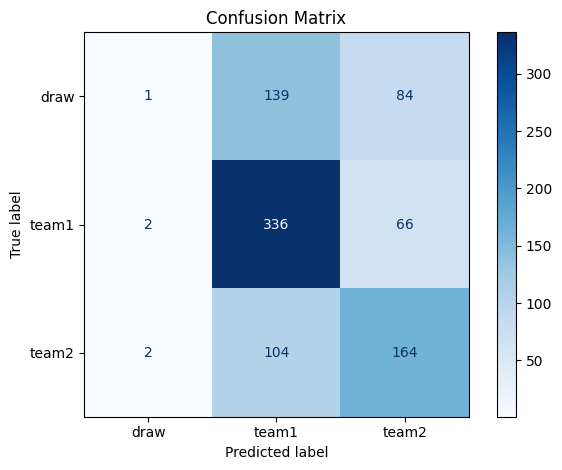

['metrics.pkl']

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import joblib

# ── build training data ───────────────────────────────────────────────────────
rows = []
for _, match in df_4yr.iterrows():
    t1 = match['home_team']
    t2 = match['away_team']
    if t1 not in team_features['team'].values or t2 not in team_features['team'].values:
        continue
    t1_stats = team_features[team_features['team'] == t1].iloc[0]
    t2_stats = team_features[team_features['team'] == t2].iloc[0]
    neutral = int(match['neutral'])
    row = {
        # ✅ difference features instead of raw stats
        'win_rate_diff':    t1_stats['overall_win_rate'] - t2_stats['overall_win_rate'],
        'goals_ratio_diff': t1_stats['goals_ratio']      - t2_stats['goals_ratio'],
        'is_neutral':       neutral,
        'result': (
            'team1' if match['winner'] == t1 else
            'team2' if match['winner'] == t2 else
            'draw'
        )
    }
    rows.append(row)

train_df = pd.DataFrame(rows)

# ── train model ───────────────────────────────────────────────────────────────
X = train_df[['win_rate_diff', 'goals_ratio_diff', 'is_neutral']]
y = train_df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# ── predictions ────────────────────────────────────────────────────────────────
y_pred = model.predict(X_test_scaled)

# ── metrics ────────────────────────────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred)
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted     = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_weighted         = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Accuracy: ", accuracy)
print("Precision (weighted):", precision_weighted)
print("Recall (weighted):   ", recall_weighted)
print("F1 Score (weighted): ", f1_weighted)

print("\nFull classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

# ── confusion matrix ───────────────────────────────────────────────────────────
labels = model.classes_  # e.g. ['draw', 'team1', 'team2']
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=labels, columns=labels))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")  # saved so you can also show it in Streamlit if you want
plt.show()

# ── save model artifacts ───────────────────────────────────────────────────────
joblib.dump(model,         'model.pkl')
joblib.dump(scaler,        'scaler.pkl')
joblib.dump(team_features, 'team_features.pkl')

# ── optional: save metrics for later display (e.g. in Streamlit) ──────────────
metrics_dict = {
    'accuracy': accuracy,
    'precision': precision_weighted,
    'recall': recall_weighted,
    'f1_score': f1_weighted,
    'confusion_matrix': cm.tolist(),
    'labels': list(labels)
}
joblib.dump(metrics_dict, 'metrics.pkl')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

# ── build training data ───────────────────────────────────────────────────────
# each row = one match, features from team_features lookup

rows = []
for _, match in df_4yr.iterrows():
    t1 = match['home_team']
    t2 = match['away_team']

    if t1 not in team_features['team'].values or t2 not in team_features['team'].values:
        continue

    t1_stats = team_features[team_features['team'] == t1].iloc[0]
    t2_stats = team_features[team_features['team'] == t2].iloc[0]

    neutral = int(match['neutral'])

    row = {
        't1_win_rate':    t1_stats['overall_win_rate'],
        't2_win_rate':    t2_stats['overall_win_rate'],
        't1_goals_ratio': t1_stats['goals_ratio'],
        't2_goals_ratio': t2_stats['goals_ratio'],
        'is_neutral':     neutral,
        'result': (
            'team1' if match['winner'] == t1 else
            'team2' if match['winner'] == t2 else
            'draw'
        )
    }
    rows.append(row)

train_df = pd.DataFrame(rows)

# ── train model ───────────────────────────────────────────────────────────────
X = train_df[['t1_win_rate','t2_win_rate','t1_goals_ratio','t2_goals_ratio','is_neutral']]
y = train_df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

# save model so streamlit can load it
joblib.dump(model, 'model.pkl')
joblib.dump(team_features, 'team_features.pkl')